# **1.FILTERS**


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [5]:
img = cv2.imread(r'c:\Users\gerayeli.k\Nextcloud2\AMU_portable\Bureau\Formation_image\Notebook\pitbull.jpg')

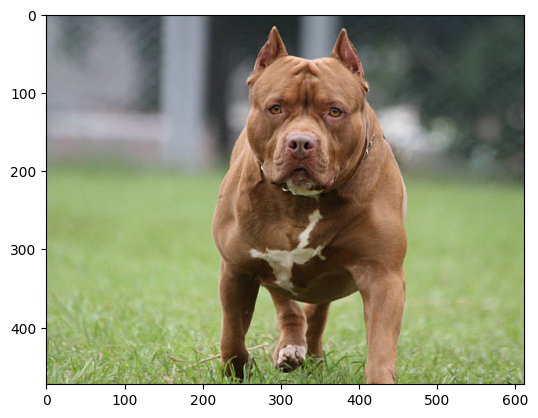

In [6]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

# *First let's explore the image itself a little bit!*

*What is the image size and type?*



In [7]:
img_rgb.shape

(473, 612, 3)

In [8]:
type(img_rgb)

numpy.ndarray

In [9]:
img_rgb

array([[[127, 137, 146],
        [128, 138, 147],
        [130, 140, 149],
        ...,
        [ 44,  56,  54],
        [ 43,  55,  53],
        [ 43,  55,  53]],

       [[127, 137, 146],
        [129, 139, 148],
        [131, 141, 150],
        ...,
        [ 43,  55,  53],
        [ 43,  55,  53],
        [ 43,  55,  53]],

       [[128, 138, 147],
        [129, 139, 148],
        [131, 141, 150],
        ...,
        [ 43,  55,  53],
        [ 43,  55,  53],
        [ 43,  55,  53]],

       ...,

       [[145, 171,  97],
        [139, 161,  96],
        [154, 172, 114],
        ...,
        [146, 157, 117],
        [146, 159, 116],
        [144, 160, 113]],

       [[153, 182,  92],
        [141, 165,  89],
        [147, 166, 102],
        ...,
        [149, 161, 125],
        [143, 158, 117],
        [136, 154, 106]],

       [[147, 171,  97],
        [130, 152,  88],
        [144, 164, 113],
        ...,
        [150, 161, 118],
        [145, 163, 113],
        [143, 166, 110]]

*Most of the time we do not need work with the 3 channels and therefore no need to keep them. We want to to have grayscale (2 channels image).*

In [10]:
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

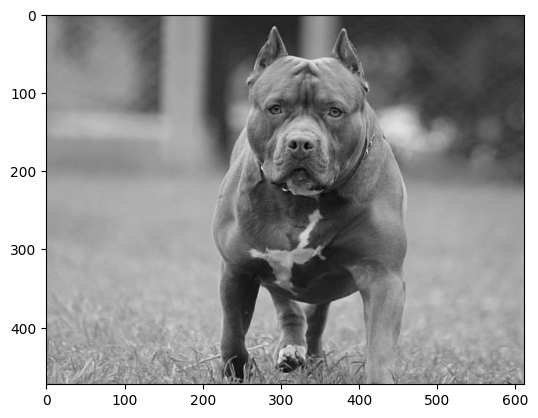

In [11]:
plt.imshow(img_gray, cmap='gray')

*Now check again if the image shape is correct! *

In [12]:
img_gray.shape

(473, 612)

### Now let's define some kernels and apply them on our image.

*1*. **Identity**

In [13]:
identity_kernel = np.array([
    [0, 0, 0],
    [0, 1, 0],
    [0, 0, 0]
])

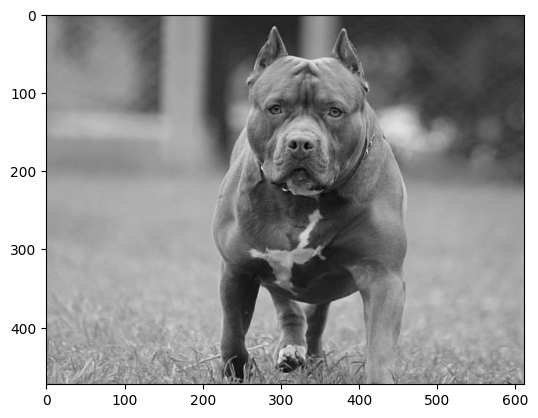

In [16]:
identity_img = cv2.filter2D(src=img,ddepth=-1, kernel=identity_kernel) # ddepth=-1 means that the output image will have the same depth as the input image, other ddepths include cv2.CV_8U, cv2.CV_16S, cv2.CV_32F, etc.
identity_img_gray = cv2.cvtColor(identity_img, cv2.COLOR_BGR2GRAY)
plt.imshow(identity_img_gray, cmap='gray')
plt.show()

*What happened?!*

*2*. **Box Blur**


*The box blur uses a kernel where all values are equal. Each pixel is averaged with its neighbors, softening sharp transitions and reducing noise.*

When to Use:



*   Quick noise reduction on fundamentally clean images.
*   Preprocessing before lower-precision tasks, such as image downsampling.


TO DO ...

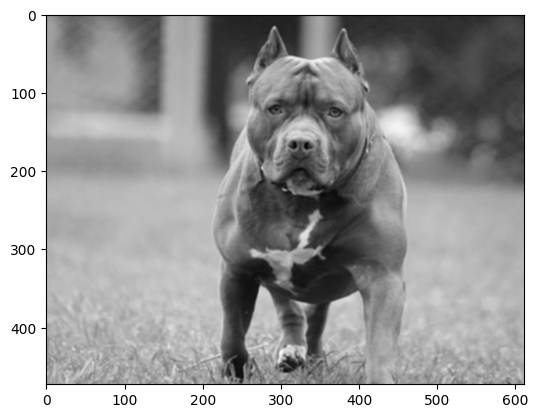

In [ ]:
box_blur_kernel = np.ones((3, 3), np.float32) / 9
box_blur = cv2.filter2D(src=img_gray, ddepth=-1, kernel=box_blur_kernel)
plt.imshow(box_blur,cmap='gray')

*let's plot them side by side!*

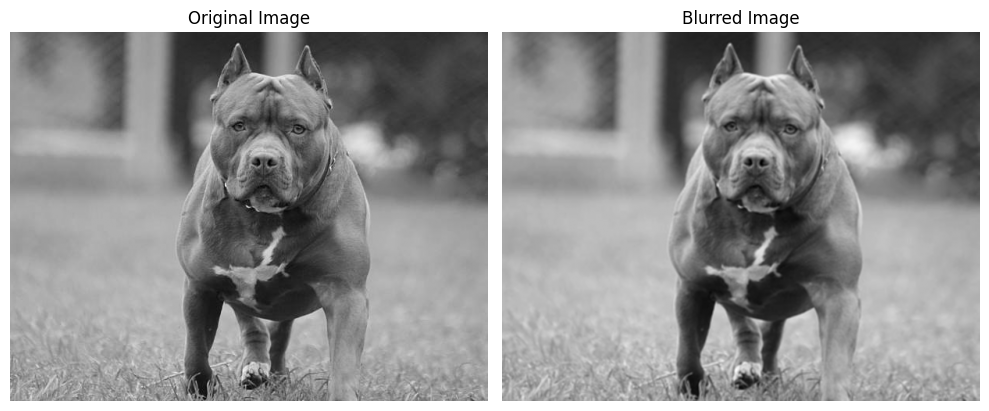

In [ ]:
# Create figure
plt.figure(figsize=(10, 5))

# First image
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title("Original Image")
plt.axis("off")

# Second image
plt.subplot(1, 2, 2)
plt.imshow(box_blur, cmap='gray')
plt.title("Blurred Image")
plt.axis("off")

plt.tight_layout()
plt.show()

*3.* **Gaussian Blur**

*Gaussian blur gives a natural smoothing effect. The kernel is weighted according to a Gaussian (bell curve). Pixels near the center contribute more, preserving overall shapes better than a box blur.*

When to Use:




*   Preprocessing for edge detection (removing random speckles before finding boundaries).
*   Mimicking depth-of-field or creating “dreamy” photo effects.



TO DO ...

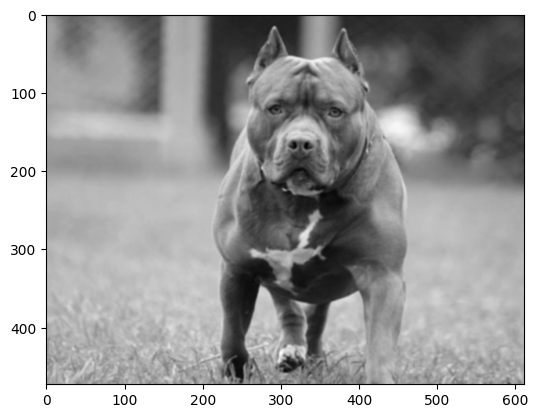

In [ ]:
gaussian_blur = cv2.GaussianBlur(src=img_gray, ksize=(5, 5), sigmaX=1)
plt.imshow(gaussian_blur, cmap='gray')

*4.* **Median Blur**

Median blur replaces each pixel with the median value of its surrounding neighborhood. This is excellent for removing isolated noise while preserving edges.

When to Use:


*   Cleaning up “salt-and-pepper” (random single-pixel) noise.
*   Restoring archival photos or scanned documents speckled with dirt.





TO DO ...

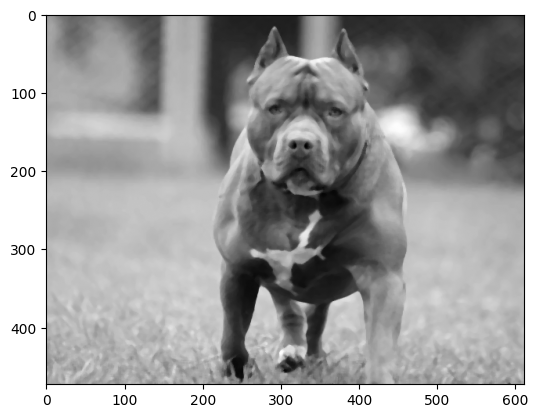

In [ ]:
median_blur = cv2.medianBlur(src=img_gray, ksize=5)
plt.imshow(median_blur, cmap='gray')

*5.* **Sharpen Filter**

A sharpening kernel increases contrast at edges, making image details stand out and appear crisp.

When to Use:


*   Making blurry or soft images crisp.
*   Highlighting details before feature extraction or texture analysis.





TO DO ...

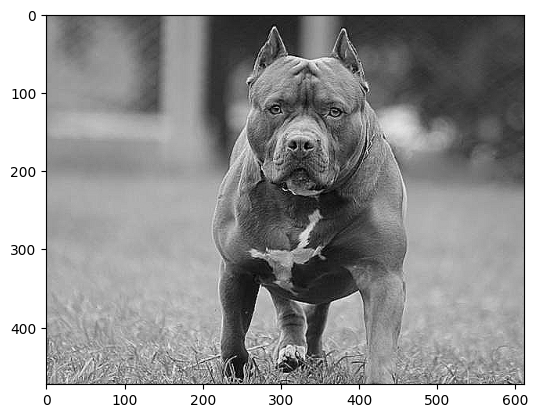

In [ ]:
sharpen_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

sharpened_img = cv2.filter2D(src=img_gray, ddepth=-1, kernel=sharpen_kernel)
plt.imshow(sharpened_img, cmap='gray')

*7.* **Edge Detection (Sobel Operator)**

Sobel filters detect dramatic intensity changes (edges) in horizontal and vertical directions. These kernels are building blocks for object boundary analysis.

When to Use:


*   Object detection and shape extraction in vision systems.
*   Automating boundary tracking for industrial inspection or robotics.





write sobel filters yourself

In [17]:
# Creating the kernel(2d convolution matrix)
edge_detection = np.array([[-1, -1, -1],
                    [-1, 8, -1],
                    [-1, -1, -1]])

In [18]:
# Applying the filter2D() function
img_edge = cv2.filter2D(src=img_gray, ddepth=-1, kernel=edge_detection)

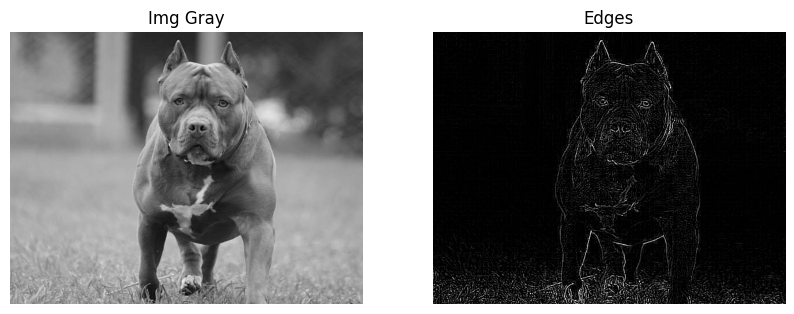

In [19]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Img Gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_edge, cmap='gray')
plt.title('Edges')
plt.axis('off')
plt.show()

In [21]:
sobelx = cv2.Sobel(src=img, ddepth=-1, dx=1, dy=0, ksize=3)
sobely = cv2.Sobel(src=img, ddepth=-1, dx=0, dy=1, ksize=3)


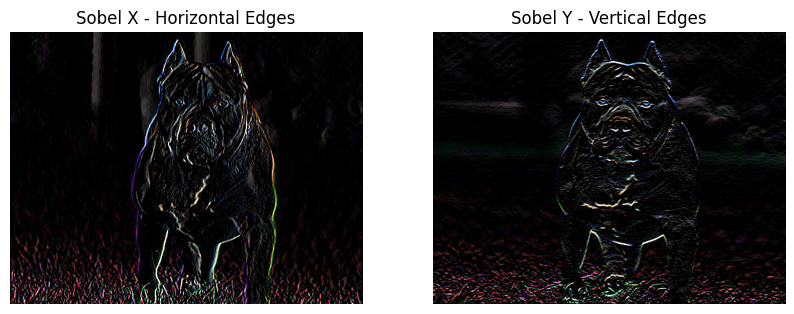

In [22]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv2.convertScaleAbs(sobelx), cmap='gray')
plt.title('Sobel X - Horizontal Edges')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.convertScaleAbs(sobely), cmap='gray')
plt.title('Sobel Y - Vertical Edges')
plt.axis('off')
plt.show()